In [1]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import glob
from pathlib import Path
import math
import numpy as np

In [ ]:
def load(set_alpha):
    all_data = {}

    # folder = Path("/Users/compneuro1/Documents/projects/continuous_learning/power_s/downloads")
    folder = Path("/Users/compneuro1/Documents/projects/continuous_learning/power_s/downloads")

    for file in folder.glob(f"auto_CL_a{set_alpha}_c*.pkl"):
        with open(file, "rb") as f:
            all_data[file.stem] = pickle.load(f)

    sorted_keys = sorted(all_data.keys(), key=lambda x: int(x.split('_c')[-1]))
    
    return all_data, sorted_keys

In [59]:
all_CL_data, sorted_CL_keys = load(0.1)

In [60]:
sorted_CL_keys

['auto_CL_a0.1_c5', 'auto_CL_a0.1_c10', 'auto_CL_a0.1_c15']

/var/folders/v2/7v9psnv97b77q1l543tr9jbw0000gn/T/ipykernel_3979/2808669054.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


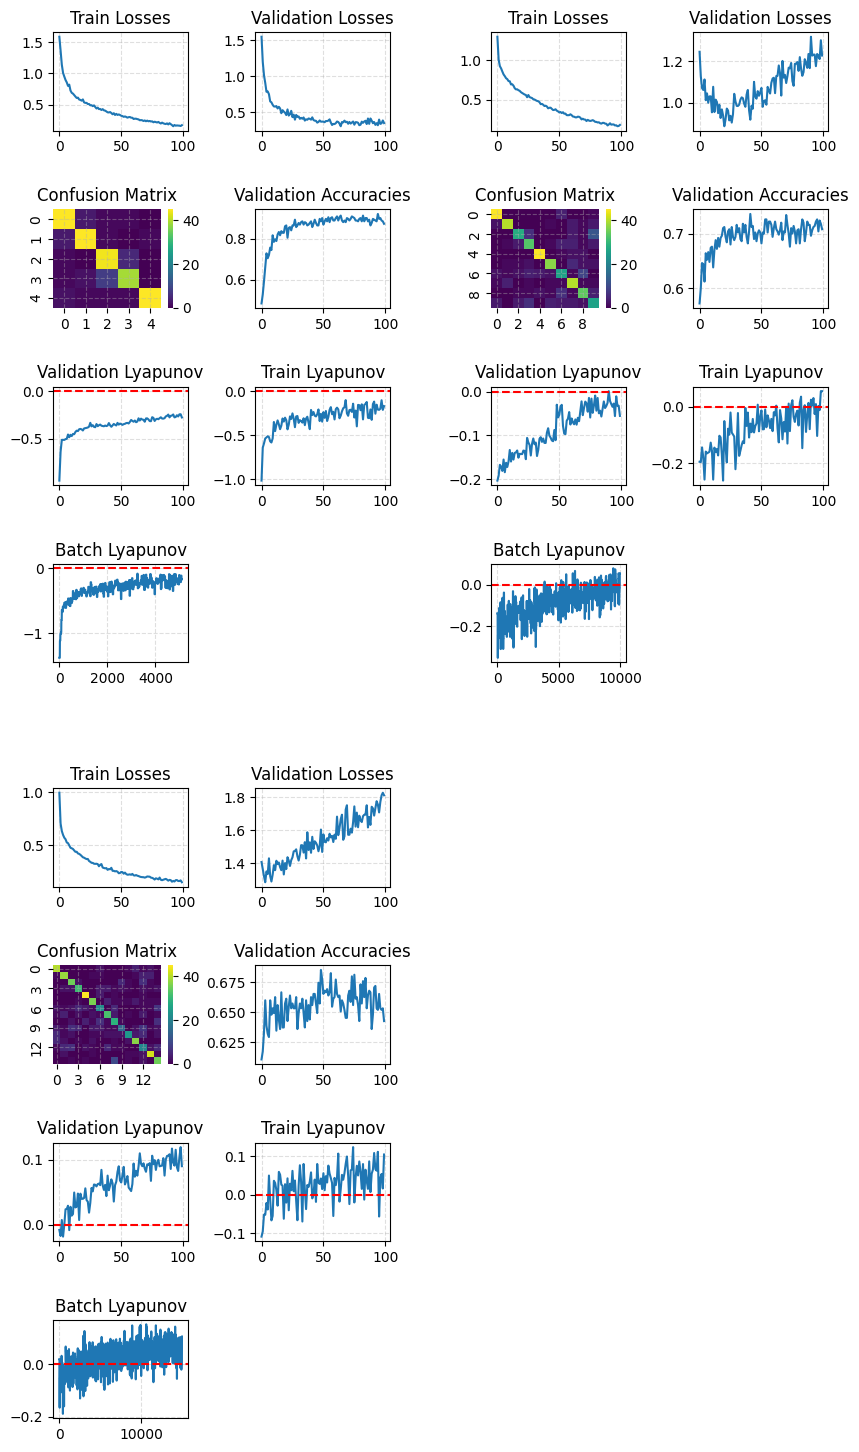

In [61]:
# plot loop
n = len(sorted_CL_keys)

n_outer_rows = 2
n_outer_cols = math.ceil(n / n_outer_rows)

dataset = all_CL_data


fig = plt.figure(figsize=(5 * n_outer_cols, 9 * n_outer_rows))
outer = gridspec.GridSpec(n_outer_rows, n_outer_cols, wspace=0.3, hspace=0.2)

for idx, i in enumerate(sorted_CL_keys):
    r = idx // n_outer_cols
    c = idx % n_outer_cols

    inner = gridspec.GridSpecFromSubplotSpec(
        4, 2,
        subplot_spec=outer[r, c],
        wspace=0.5,
        hspace=0.8
    )

    axes = [fig.add_subplot(inner[r_, c_]) for r_ in range(4) for c_ in range(2)]
    axes = [axes[j:j+2] for j in range(0, len(axes), 2)]
    
    axes[0][0].plot(dataset[i]["train_losses"])
    axes[0][0].set_title("Train Losses")

    axes[0][1].plot(dataset[i]["val_losses"])
    axes[0][1].set_title("Validation Losses")

    sns.heatmap(dataset[i]["confusion_matrices"][-1], ax=axes[1][0], cmap="viridis")
    axes[1][0].set_title("Confusion Matrix")

    axes[1][1].plot(dataset[i]["val_accuracies"])
    axes[1][1].set_title("Validation Accuracies")

    axes[2][0].plot(dataset[i]["lyas"])
    axes[2][0].axhline(y=0, linestyle='--', color='red')
    axes[2][0].set_title("Validation Lyapunov")

    axes[2][1].plot(dataset[i]["lya_train"])
    axes[2][1].axhline(y=0, linestyle='--', color='red')
    axes[2][1].set_title("Train Lyapunov")

    axes[3][0].plot(dataset[i]["records"])
    axes[3][0].axhline(y=0, linestyle='--', color='red')
    axes[3][0].set_title("Batch Lyapunov")

    axes[3][1].axis("off")

    for row_axes in axes:
        for ax in row_axes:
            ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
# fig.savefig("10.png", dpi=300)

In [6]:
alpha_list = [0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

Calculate accuracies and lyas

In [11]:
def acc_lya(alpha_list):
    acc_list = []
    lya_list = []

    for a in alpha_list:
        acc_a_list = []
        lya_a_list = []

        all_data = {}

        folder = Path("/Users/compneuro1/Documents/projects/continuous_learning/power_s/downloads")

        for file in folder.glob(f"auto_CL_a{a}_c*.pkl"):
            with open(file, "rb") as f:
                all_data[file.stem] = pickle.load(f)

        sorted_keys = sorted(all_data.keys(), key=lambda x: int(x.split('_c')[-1]))

        for k in sorted_keys:
            acc_a_list.append(all_data[k]["val_accuracies"])
            lya_a_list.append(all_data[k]["lya_train"])
        acc_list.append(acc_a_list)
        lya_list.append(lya_a_list)
    
    return acc_list, lya_list

In [12]:
acc_list, lya_list = acc_lya(alpha_list)

In [13]:
acc_list = np.array(acc_list)
lya_list = np.array(lya_list)

In [14]:
lya_list.shape

(7, 9, 100)

In [15]:
acc_list.shape

(7, 9, 100)

In [9]:
alpha_list

[0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

In [ ]:
arr = acc_list

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

for plot_idx in range(6):
    ax = axes[plot_idx]
    
    for line_idx in range(7):  # 6 lines per subplot
        if line_idx == 0:
            pass
        else:
            ax.plot(arr[line_idx, plot_idx, :], label=f"alpha {alpha_list[line_idx]}")
    
    ax.set_title(f"Classes {5 + 5*plot_idx}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy")
    ax.grid(True, linestyle="--", alpha=0.4)
    # ax.axhline(y=0, linestyle='--', color="red")

    # optional legend
    ax.legend(fontsize=8)

plt.tight_layout()
# plt.savefig("acc_all.png", dpi=300)
plt.show()

In [65]:
lya_list.shape

(6, 6, 100)

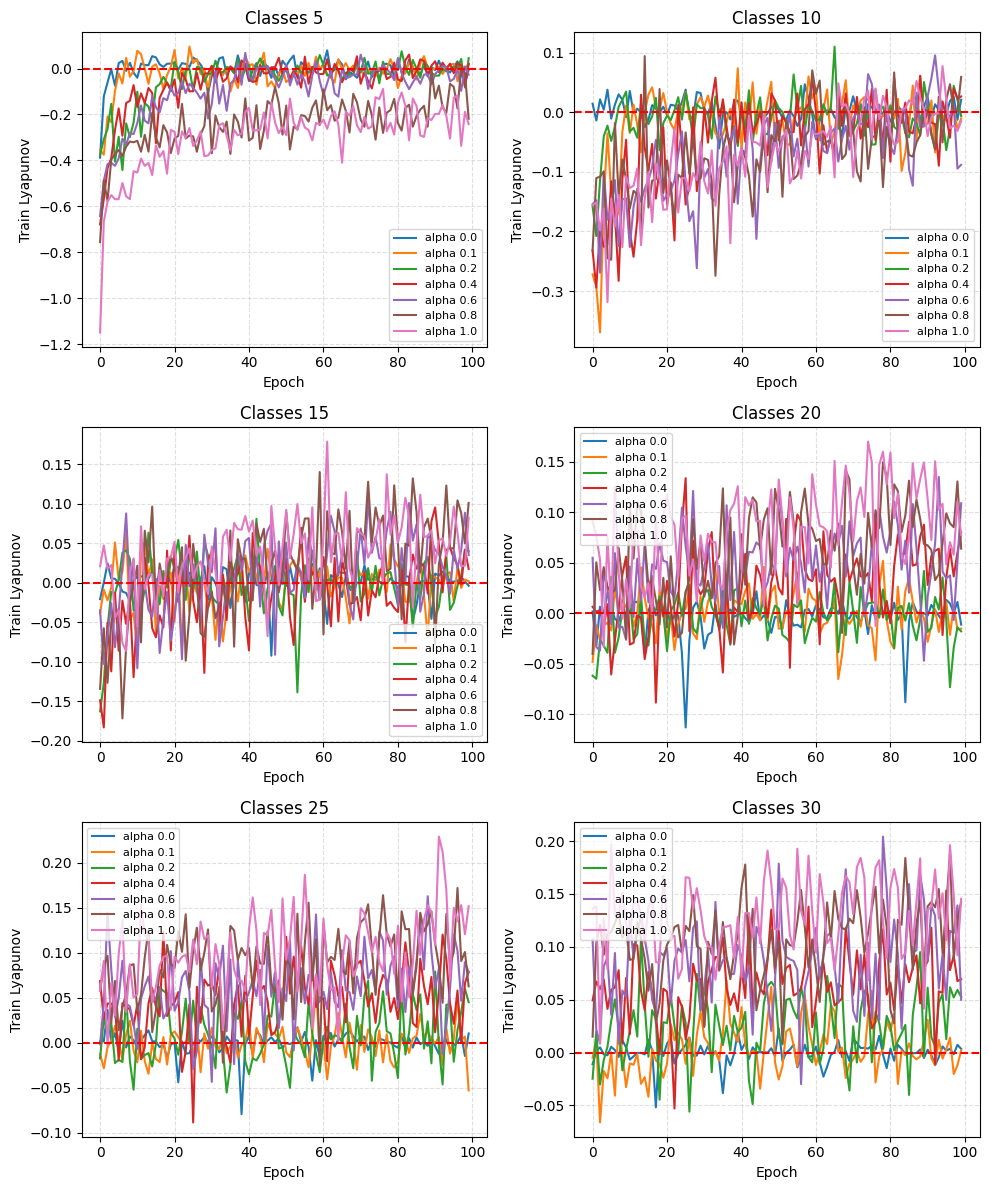

In [85]:
arr = lya_list

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

for plot_idx in range(6):  # 4 subplots
    ax = axes[plot_idx]
    
    for line_idx in range(7):  # 6 lines per subplot
        ax.plot(arr[line_idx, plot_idx, :], label=f"alpha {alpha_list[line_idx]}")
        # ax.plot(arr[line_idx][plot_idx][:], label=f"alpha {alpha_list[line_idx]}")
    
    ax.set_title(f"Classes {5 + 5*plot_idx}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train Lyapunov")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.axhline(y=0, linestyle='--', color="red")

    # optional legend
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("lya_all.png", dpi=300)
plt.show()

In [16]:
def average_last(arr):
    return arr[..., -10:].mean(axis=-1)

In [17]:
lya = average_last(lya_list)
acc = average_last(acc_list)

In [18]:
lya

array([[ 0.00228767, -0.00399289, -0.0015829 ,  0.00064243,  0.00067208,
         0.00301699,  0.00345659,  0.00209189,  0.00183676],
       [ 0.00148319, -0.00405044, -0.0081493 , -0.00249598, -0.00171344,
         0.00117426,  0.01623527,  0.01969906,  0.020614  ],
       [ 0.00666443, -0.00984787,  0.00420899,  0.01743335,  0.02642449,
         0.04858631,  0.04966169,  0.0529932 ,  0.0594279 ],
       [-0.02885509,  0.00847302,  0.00130303,  0.02923306,  0.05832123,
         0.0702422 ,  0.07760109,  0.07349111,  0.0827467 ],
       [-0.10835208, -0.02402509,  0.00172975,  0.04127945,  0.08966296,
         0.07939169,  0.11020266,  0.11635479,  0.13699023],
       [-0.13917122, -0.01036472,  0.0500421 ,  0.07565515,  0.09887046,
         0.13324787,  0.15854201,  0.15605975,  0.17341397],
       [-0.19552256, -0.00705674,  0.08743452,  0.12723866,  0.14783519,
         0.17279691,  0.16372242,  0.2023002 ,  0.21007761]])

In [19]:
x = [5,10,15,20,25,30,35,40,45]

In [20]:
alpha_list

[0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

In [23]:
arr.shape

(7, 3, 100)

In [26]:
x = [5,10,15]

In [21]:
acc_new = acc
lya_new = lya

In [22]:
again_acc = acc

In [23]:
again_acc.shape

(7, 9)

In [32]:
acc.shape

(7, 6)

In [33]:
type(acc)

numpy.ndarray

In [34]:
stacked = np.stack([again_acc, acc], axis=0)

In [38]:
means = np.mean(stacked, axis=0)
stds = np.std(stacked, axis=0)

In [39]:
means.shape

(7, 6)

/var/folders/v2/7v9psnv97b77q1l543tr9jbw0000gn/T/ipykernel_15615/1427181022.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


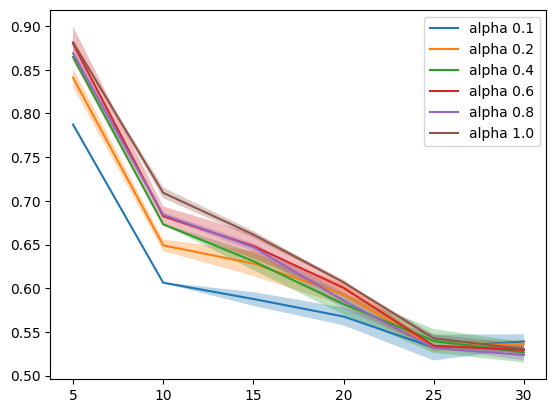

In [48]:
for i in range(means.shape[0]):

    if i == 0:
        pass
    else:
        plt.plot(x, means[i], label=f"alpha {alpha_list[i]}")

        plt.fill_between(
            x,
            means[i] - stds[i],
            means[i] + stds[i],
            alpha=0.3
        )

    plt.legend()

plt.savefig("two_time.png", dpi=300)

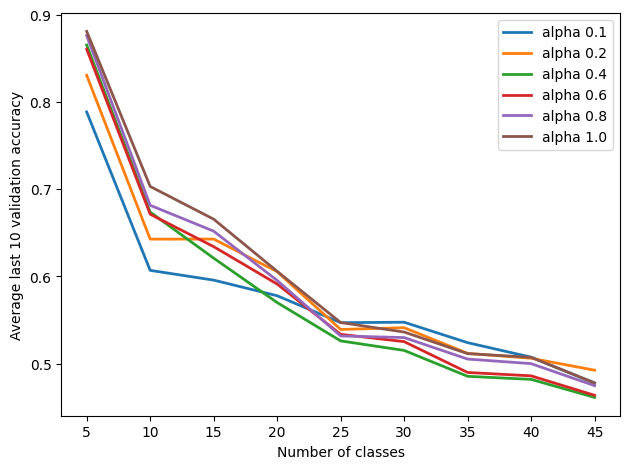

In [27]:
arr = again_acc

for i in range(arr.shape[0]):
    if i == 0:
        pass
    else:
        plt.plot(x, arr[i], label=f"alpha {alpha_list[i]}", linewidth=2)

plt.xticks(x)

plt.xlabel("Number of classes")
plt.ylabel("Average last 10 validation accuracy")

plt.legend()

plt.tight_layout()
plt.savefig("more_classes.png", dpi=300)
plt.show()

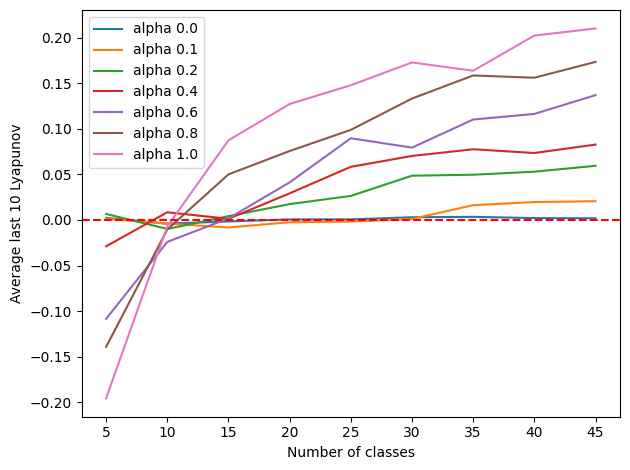

In [28]:
arr = lya

for i in range(arr.shape[0]):
    # if i == 0:
    #     pass
    # else:
        plt.plot(x, arr[i], label=f"alpha {alpha_list[i]}")

plt.xticks(x)

plt.xlabel("Number of classes")
plt.ylabel("Average last 10 Lyapunov")

plt.axhline(y=0, color='red', linestyle="--")

plt.legend()

plt.tight_layout()
plt.savefig("lyas_more_classes.png", dpi=300)
plt.show()

In [ ]:
# plot loop
for i in sorted_CL_keys_2:
    fig, axes = plt.subplots(3,2, figsize=(8,10))

    dataset = all_CL_data_2

    plt.subplots_adjust(
        wspace=0.5,
        hspace=0.5
    )

    axes[0,0].plot(dataset[i]["train_losses"])
    axes[0,0].set_title("Train Losses")
    axes[0,0].set_xlabel("Epoch")
    axes[0,0].set_ylabel("Loss")

    axes[0,1].plot(dataset[i]["val_losses"])
    axes[0,1].set_title("Validation Losses")
    axes[0,1].set_xlabel("Epoch")
    axes[0,1].set_ylabel("Loss")

    sns.heatmap(dataset[i]["confusion_matrices"][-1], ax=axes[1,0], cmap="viridis")
    axes[1,0].set_title("Confusion Matrix")

    axes[1,1].plot(dataset[i]["val_accuracies"])
    axes[1,1].set_title("Validation Accuracies")
    axes[1,1].set_xlabel("Epoch")
    axes[1,1].set_ylabel("Accuracy")

    axes[2,0].plot(dataset[i]["lyas"])
    axes[2,0].set_title("Lyapunov")
    axes[2,0].set_xlabel("Epoch")
    axes[2,0].set_ylabel("Lyapunov")

    axes[2,1].axis("off")

    for ax in axes.flatten():
        ax.grid(True, linestyle="--", alpha=0.4)

    plt.savefig(f"{i}.png", dpi=300)

In [62]:
def average(lst):
    last_10 = lst[-10:]
    return sum(last_10)/len(last_10)

In [93]:
SL_val_accuracies_0 = []
for i in sorted_SL_keys_0:
    SL_val_accuracies_0.append(average(all_SL_data_0[i]["val_accuracies"]))

In [94]:
SL_val_accuracies_1 = []
for i in sorted_SL_keys_1:
    SL_val_accuracies_1.append(average(all_SL_data_1[i]["val_accuracies"]))

In [71]:
L_val_accuracies = []
for i in sorted_L_keys[:]:
    L_val_accuracies.append(average(all_L_data[i]["val_accuracies"]))

In [72]:
CL_val_accuracies_4 = []
for i in sorted_CL_keys_4:
    CL_val_accuracies_4.append(average(all_CL_data_4[i]["val_accuracies"]))

CL_val_accuracies_6 = []
for i in sorted_CL_keys_6:
    CL_val_accuracies_6.append(average(all_CL_data_6[i]["val_accuracies"]))

CL_val_accuracies_8 = []
for i in sorted_CL_keys_8:
    CL_val_accuracies_8.append(average(all_CL_data_8[i]["val_accuracies"]))

In [104]:
CL_val_accuracies_2 = []
for i in sorted_CL_keys_2:
    CL_val_accuracies_2.append(average(all_CL_data_2[i]["val_accuracies"]))

In [98]:
import numpy as np
SL_val_accuracies_0 = np.array(SL_val_accuracies_0)
SL_val_accuracies_1 = np.array(SL_val_accuracies_1)
# SL_val_2_accuracies = np.array(SL_val_2_accuracies)
# SL_val_3_accuracies = np.array(SL_val_3_accuracies)
SLs = np.stack([SL_val_accuracies_0, SL_val_accuracies_1])
mean = SLs.mean(axis=0)
std = SLs.std(axis=0)

In [112]:
dict_sl_l = {
    'SL_mean': mean,
    'SL_std': std,
    'L_val_accuracies': L_val_accuracies
}

In [ ]:
# with open("SL_L.pkl", 'wb') as f:
#     pickle.dump(dict_sl_l, f)

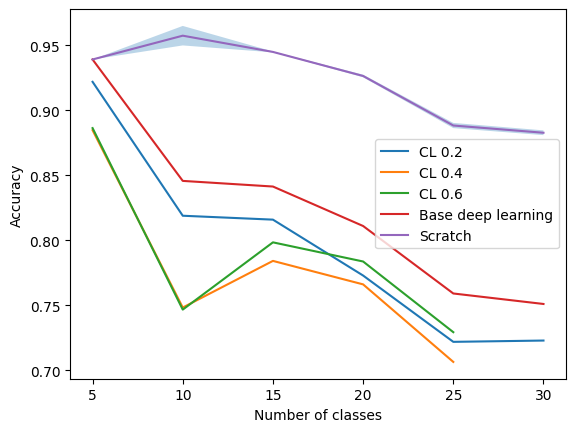

In [109]:
# x1= [5,10,15,20,25]
x= [5,10,15,20,25,30]
plt.plot(x, CL_val_accuracies_2, label="CL 0.2")
plt.plot(x[:-1], CL_val_accuracies_4, label="CL 0.4")
plt.plot(x[:-1], CL_val_accuracies_6, label="CL 0.6")
# plt.plot(x[:-1], CL_val_accuracies_8, label="CL 0.8")
plt.plot(x, L_val_accuracies, label="Base deep learning")

# plot scratch
plt.plot(x, mean, label="Scratch")
plt.fill_between(x, mean - std, mean + std, alpha=0.3)

plt.xlabel("Number of classes")
plt.ylabel("Accuracy")
plt.xticks([5,10,15,20,25,30])
plt.legend()
# plt.savefig("CL_L_compare.png", dpi=300)

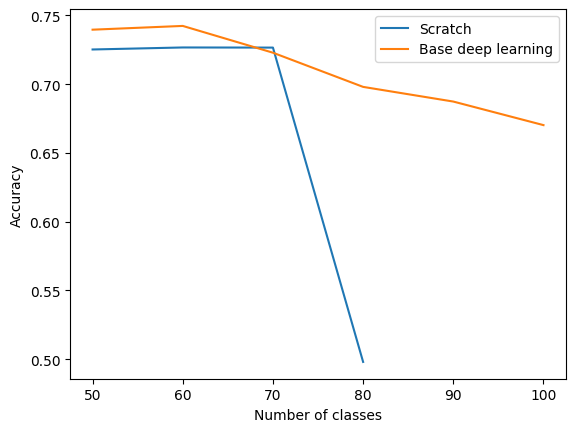

In [19]:
x1= [50,60,70,80]
x2= [50,60,70,80,90,100]
plt.plot(x1, SL_val_accuracies, label="Scratch")
plt.plot(x2, L_val_accuracies, label="Base deep learning")
plt.xlabel("Number of classes")
plt.ylabel("Accuracy")
plt.xticks([50,60,70,80,90,100])
plt.legend()
# plt.savefig("compare_val_acc.png", dpi=300)

In [39]:
import numpy as np

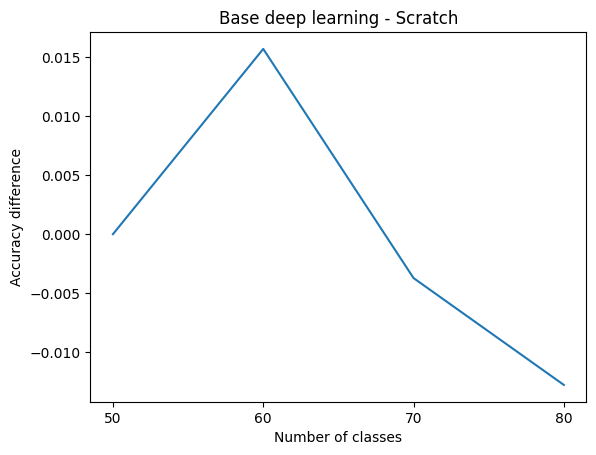

In [42]:
plt.plot([50,60,70,80], np.array(L_val_accuracies[:-1])-np.array(SL_val_accuracies))
plt.title("Base deep learning - Scratch")
plt.xlabel("Number of classes")
plt.ylabel("Accuracy difference")
plt.xticks([50,60,70,80])
plt.savefig("val_acc_difference.png", dpi=300)

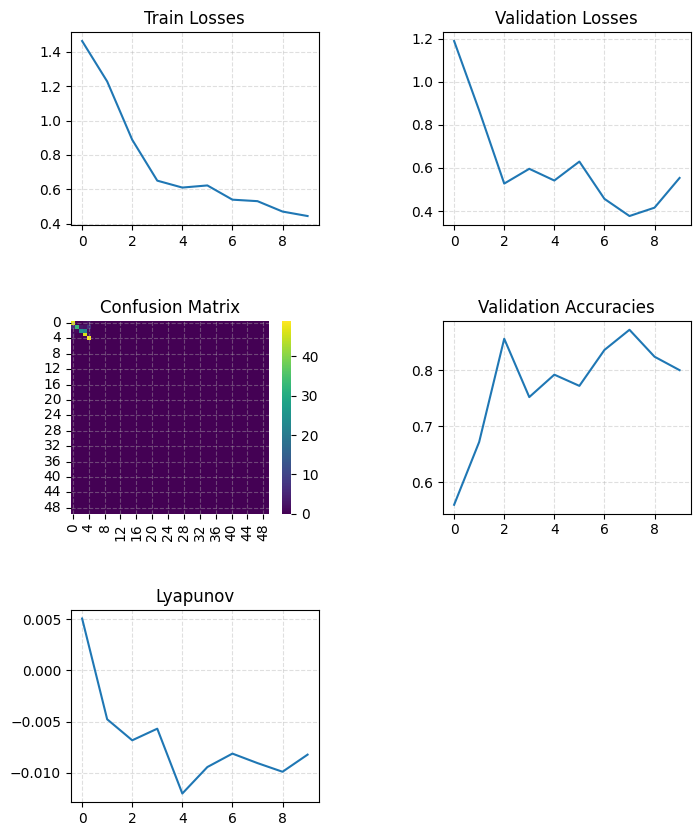

In [61]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("c5_CL_5.png", dpi=300)

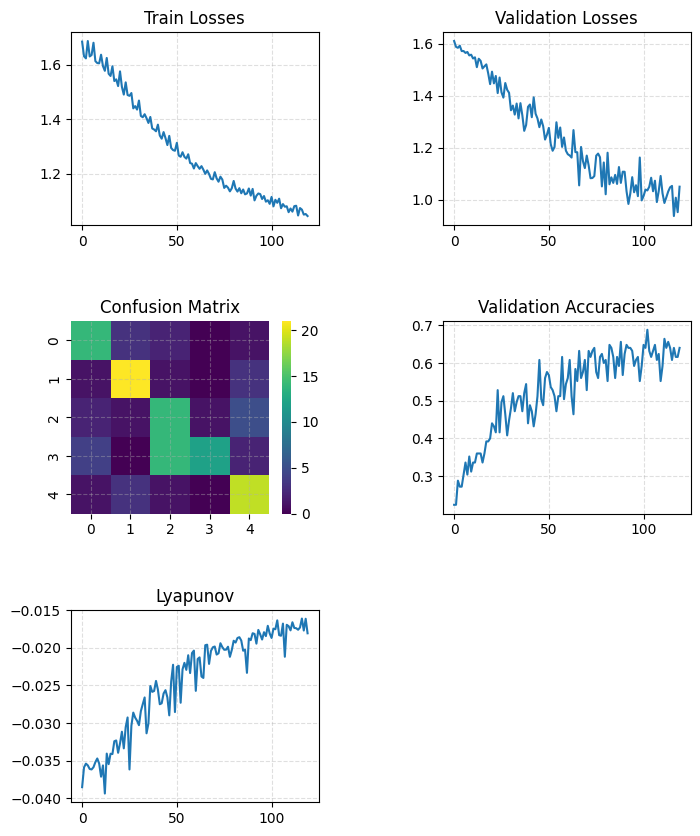

In [19]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

In [10]:
val_accuracies[-1]

0.3815999925136566

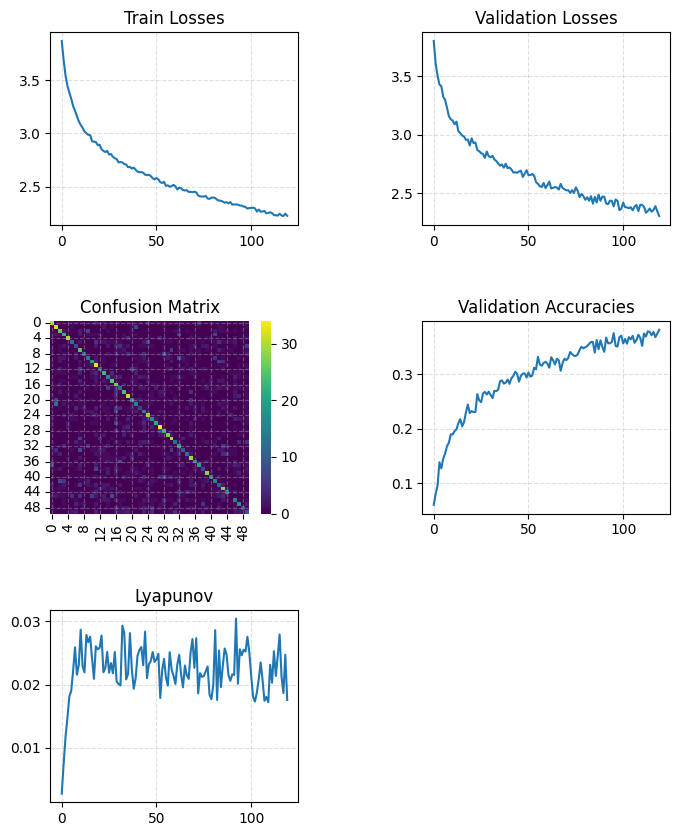

In [9]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

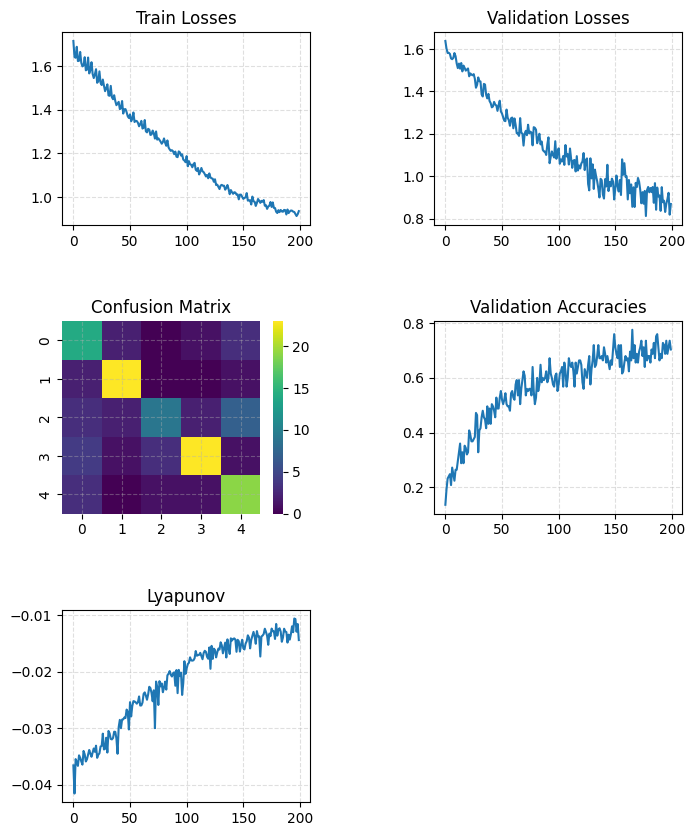

In [5]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

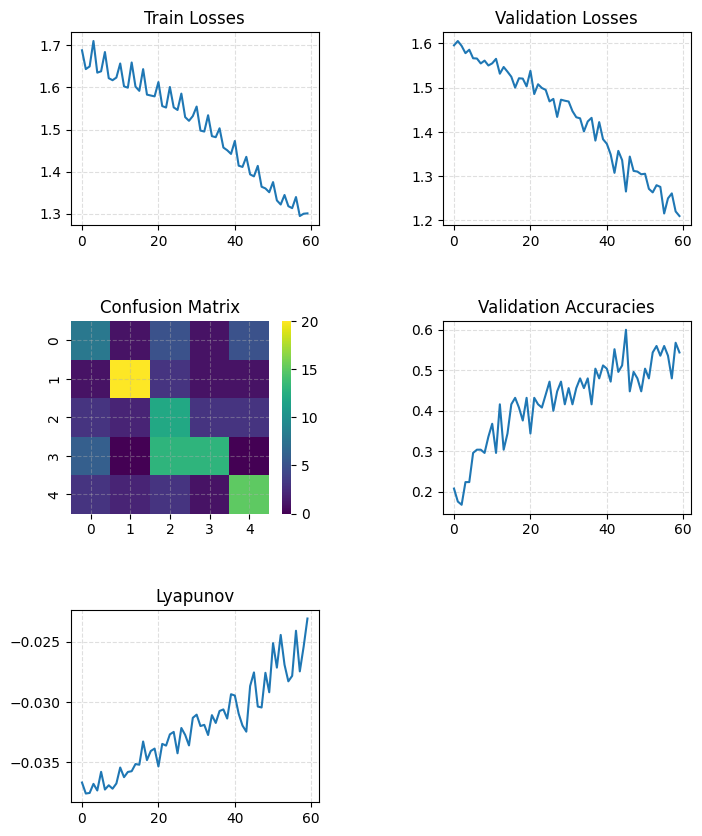

In [16]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

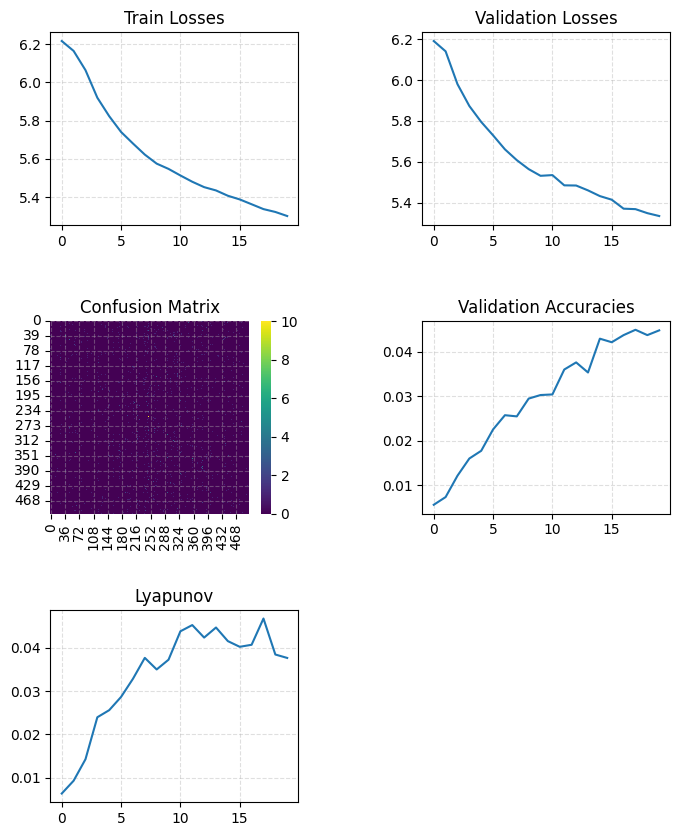

In [23]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

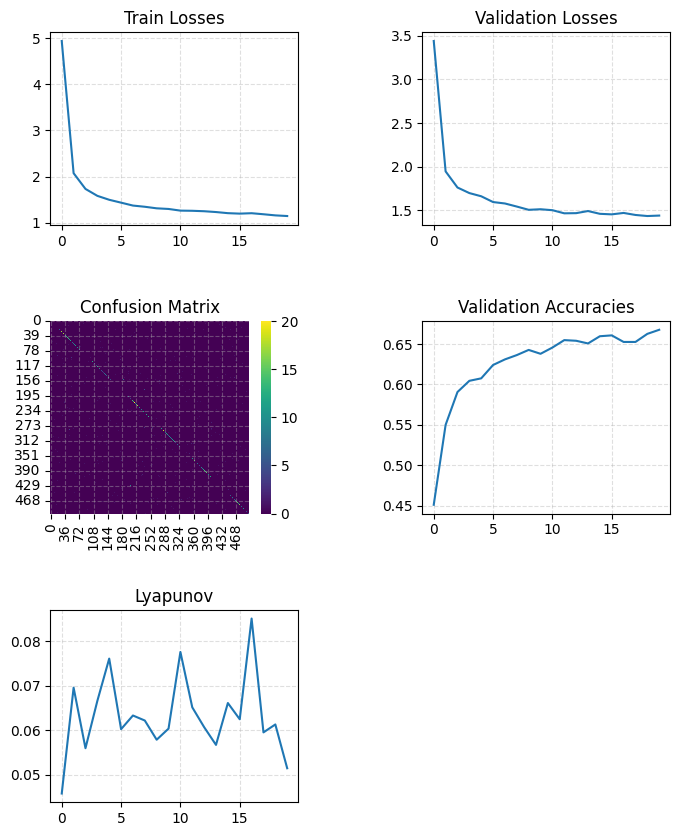

In [14]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

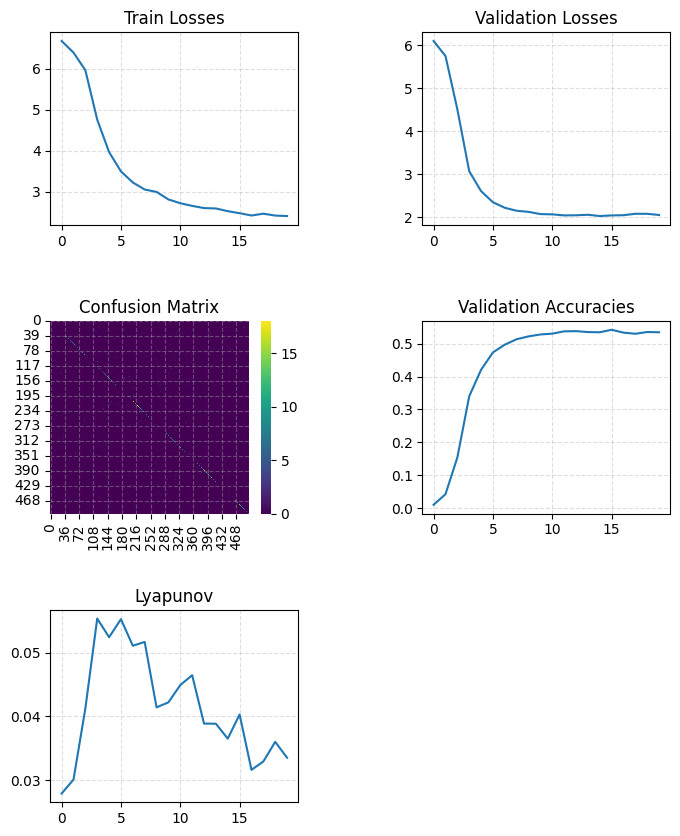

In [10]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

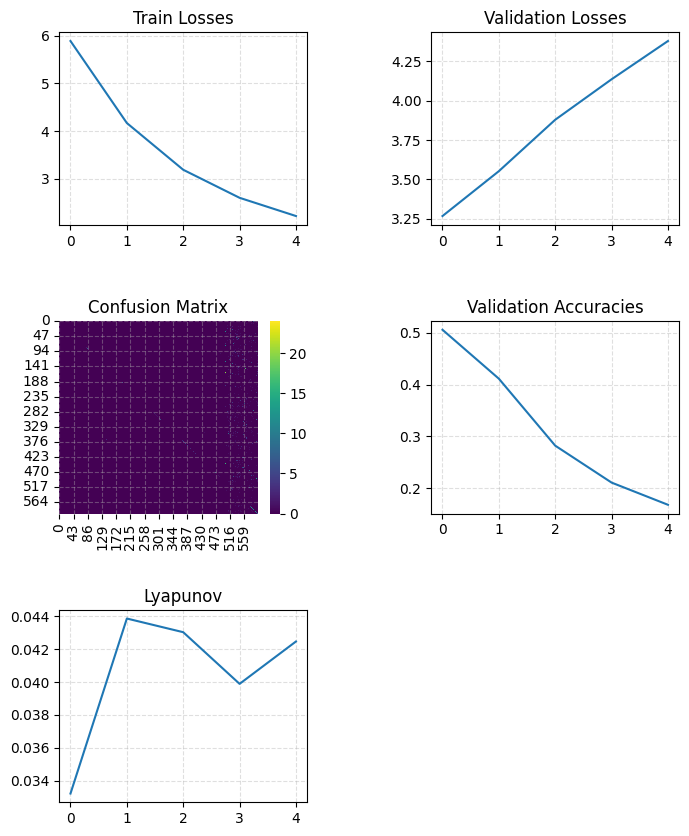

In [27]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("200c_60e_param1.png", dpi=300)

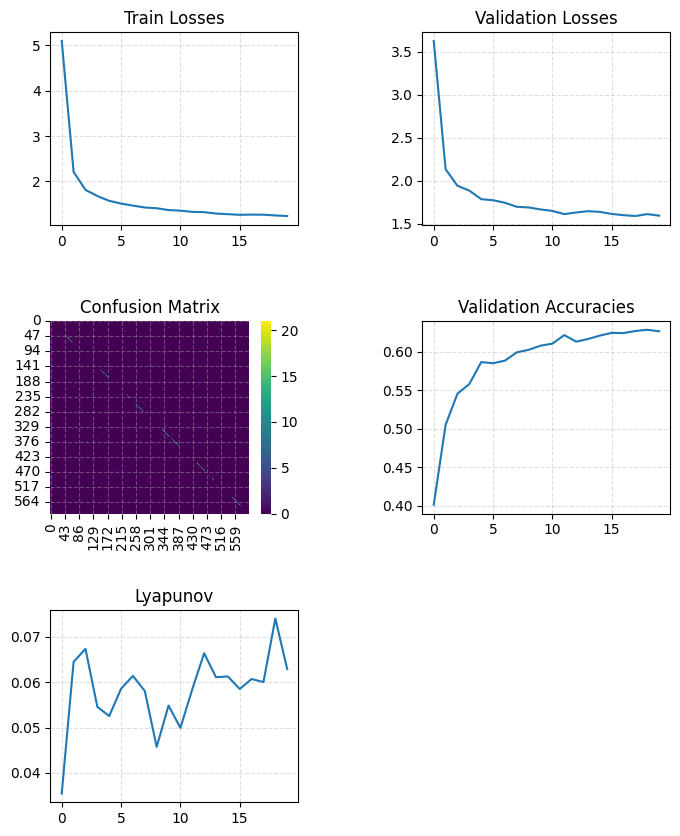

In [12]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("200c_60e_param1.png", dpi=300)

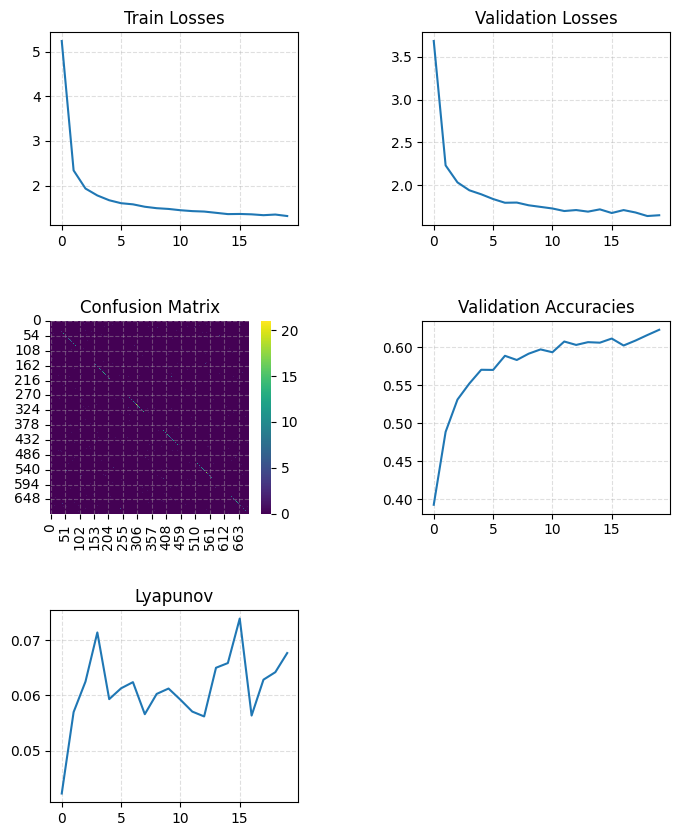

In [16]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("200c_60e_param1.png", dpi=300)

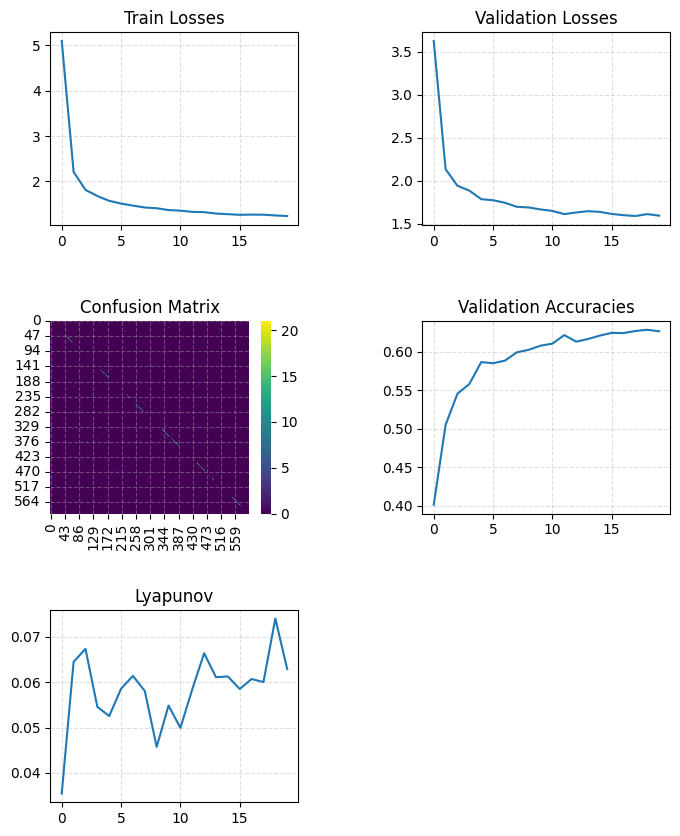

In [54]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("200c_60e_param1.png", dpi=300)

In [12]:
val_accuracies

[]

In [6]:
val_accuracies

[tensor(0.2743)]